In [1]:
import pandas as pd
import ast
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = {
    # BERT
    "BERT-base_MH": "../results/BERT_base_EN_MH.csv",
    "BERT-base_non-MH": "../results/BERT_base_EN_non_MH.csv",
    "AnorBERT_MH": "../results/AnorBERT_EN_MH.csv",
    "AnorBERT_non-MH": "../results/AnorBERT_EN_non_MH.csv",
    "DepBERT_MH": "../results/DepBERT_EN_MH.csv",
    "DepBERT_non-MH": "../results/DepBERT_EN_non_MH.csv",
    "DisorBERT_MH": "../results/DisorBERT_EN_MH.csv",
    "DisorBERT_non-MH": "../results/DisorBERT_EN_non_MH.csv",
    "GambBERT_MH": "../results/GambBERT_EN_MH.csv",
    "GambBERT_non-MH": "../results/GambBERT_EN_non_MH.csv",
    "SHBERT_MH": "../results/SHBERT_EN_MH.csv",
    "SHBERT_non-MH": "../results/SHBERT_EN_non_MH.csv",
    "WholeBERT_MH": "../results/WholeBERT_EN_MH.csv",
    "WholeBERT_non-MH": "../results/WholeBERT_EN_non_MH.csv",
    # RoBERTa
    "RoBERTa-base_MH": "../results/RoBERTa_base_EN_MH.csv",
    "RoBERTa-base_non-MH": "../results/RoBERTa_base_EN_non_MH.csv",
    "AnorRoBERTa_MH": "../results/AnorRoBERTa_EN_MH.csv",
    "AnorRoBERTa_non-MH": "../results/AnorRoBERTa_EN_non_MH.csv",
    "DepRoBERTa_MH": "../results/DepRoBERTa_EN_MH.csv",
    "DepRoBERTa_non-MH": "../results/DepRoBERTa_EN_non_MH.csv",
    "DisorRoBERTa_MH": "../results/DisorRoBERTa_EN_MH.csv",
    "DisorRoBERTa_non-MH": "../results/DisorRoBERTa_EN_non_MH.csv",
    "GambRoBERTa_MH": "../results/GambRoBERTa_EN_MH.csv",
    "GambRoBERTa_non-MH": "../results/GambRoBERTa_EN_non_MH.csv",
    "SHRoBERTa_MH": "../results/SHRoBERTa_EN_MH.csv",
    "SHRoBERTa_non-MH": "../results/SHRoBERTa_EN_non_MH.csv",
    # BETO
    "BETO_MH": "../results/BETO_ES_MH.csv",
    "BETO_non-MH": "../results/BETO_ES_non_MH.csv",
    "ludoBETO_MH": "../results/ludoBETO_ES_MH.csv",
    "ludoBETO_non-MH": "../results/ludoBETO_ES_non_MH.csv"
}

dfs = []
for name, path in results.items():
    model_name, health_type = name.split('_')
    temp_df = pd.read_csv(path)
    temp_df['model'] = model_name
    temp_df['health'] = health_type
    dfs.append(temp_df)

full_data = pd.concat(dfs, ignore_index = True)
print(f"Dataset cargado: {full_data.shape[0]} observaciones de {full_data['diagnosis'].nunique()} diagnósticos.")

Dataset cargado: 5610 observaciones de 39 diagnósticos.


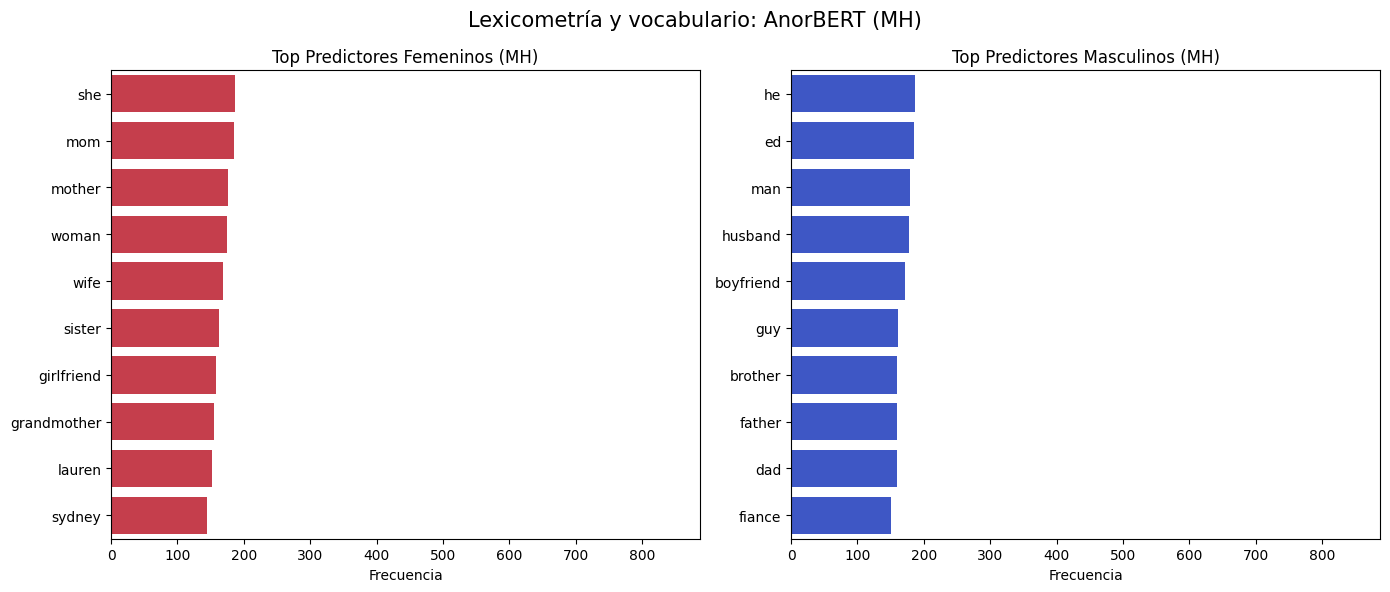

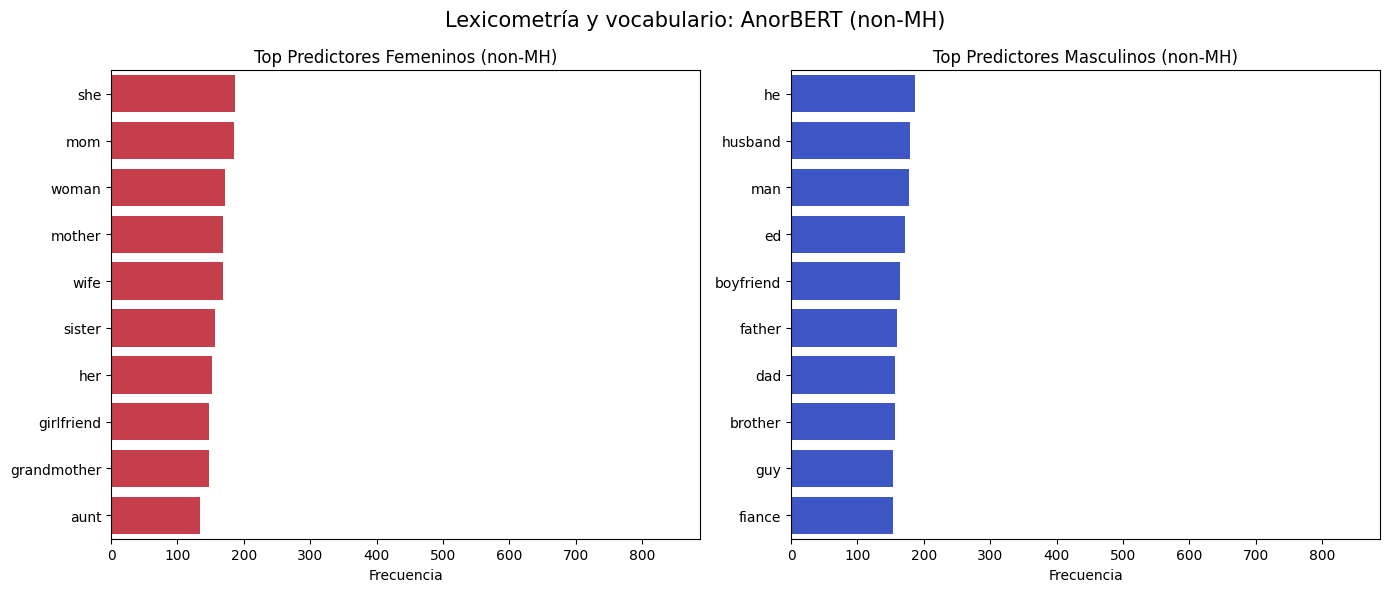

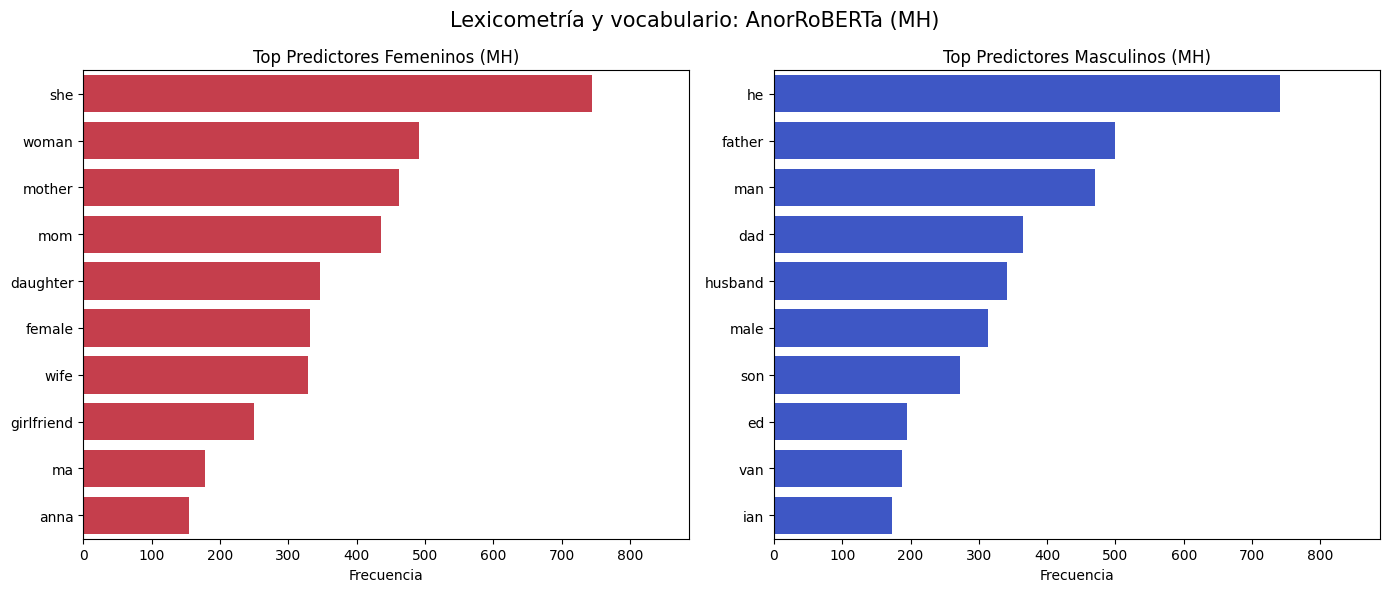

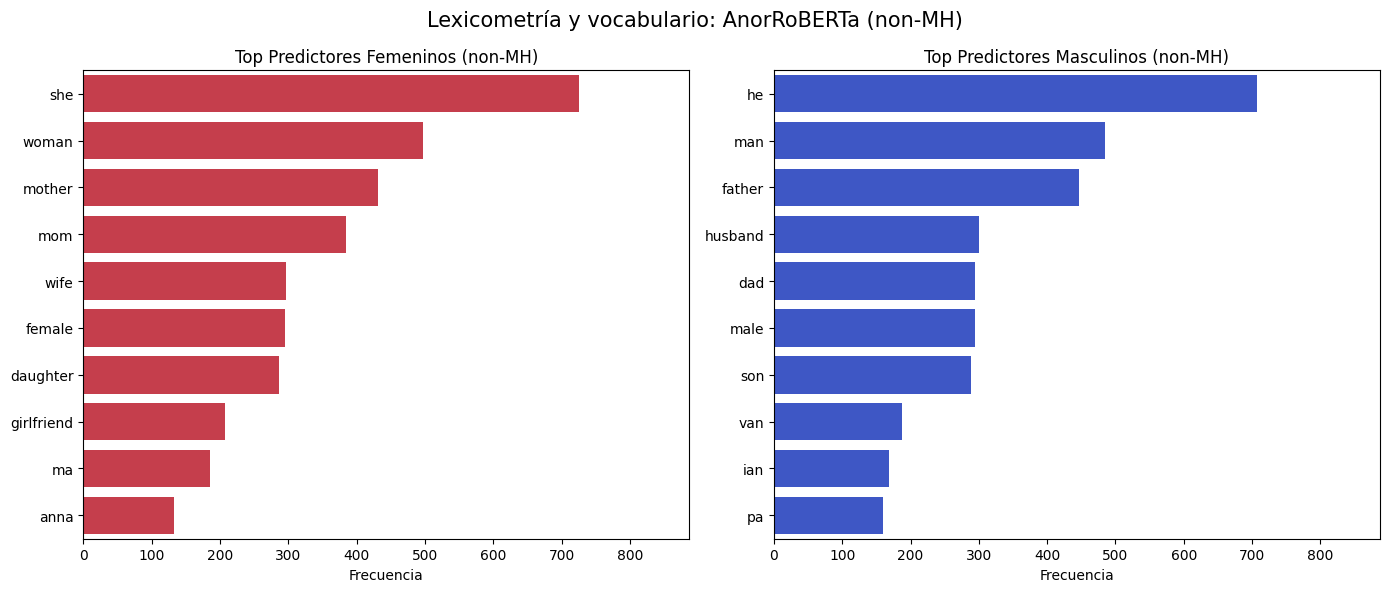

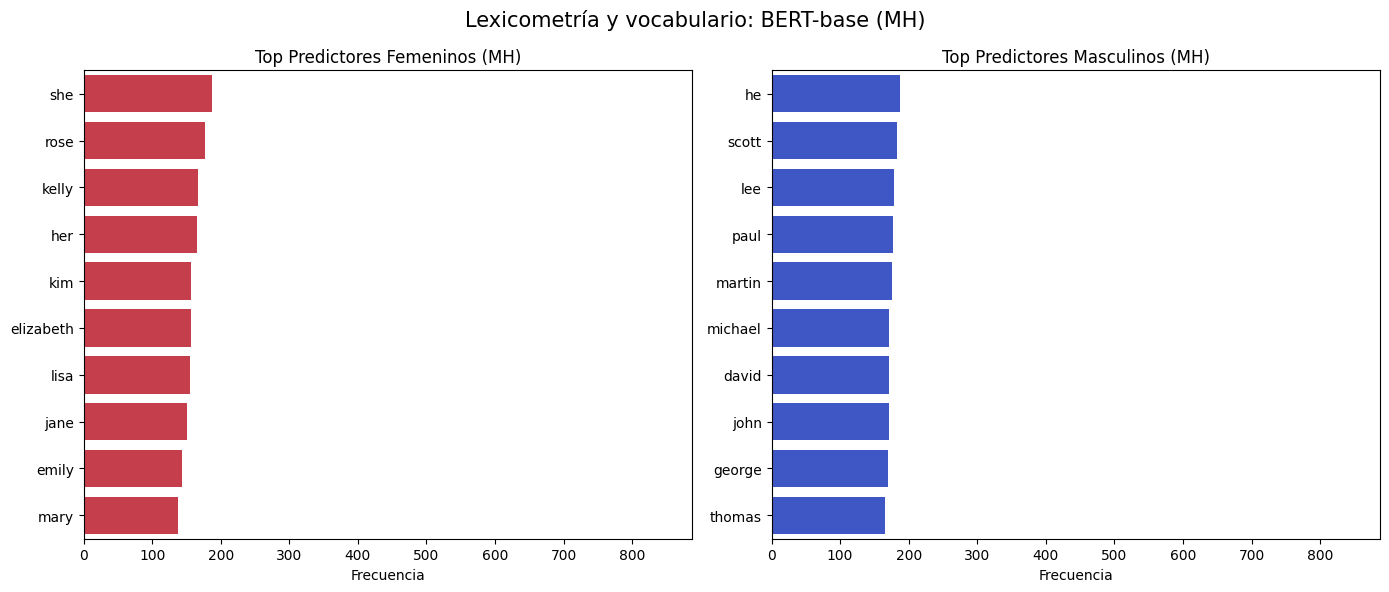

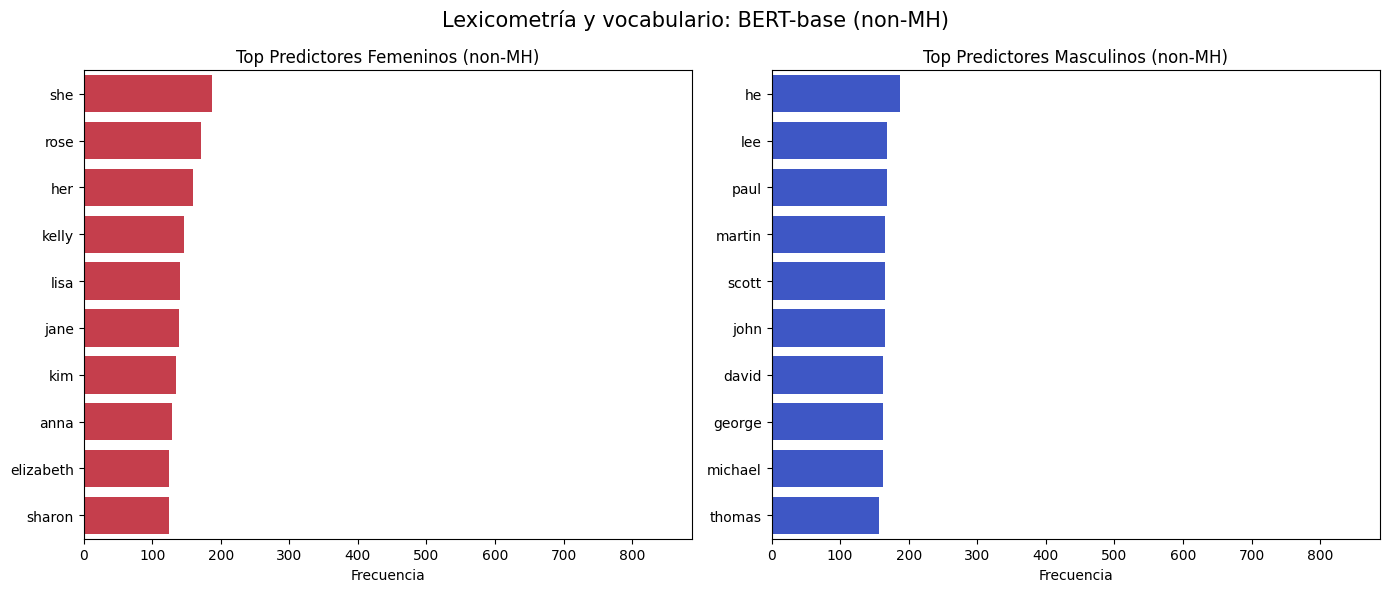

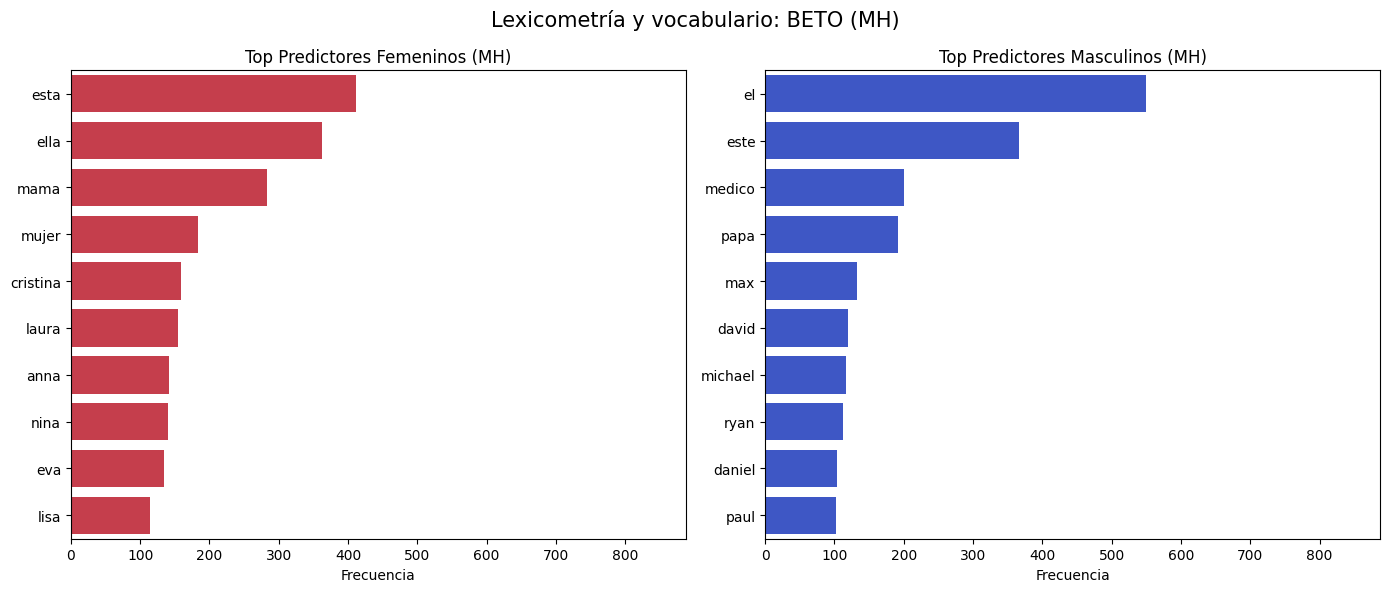

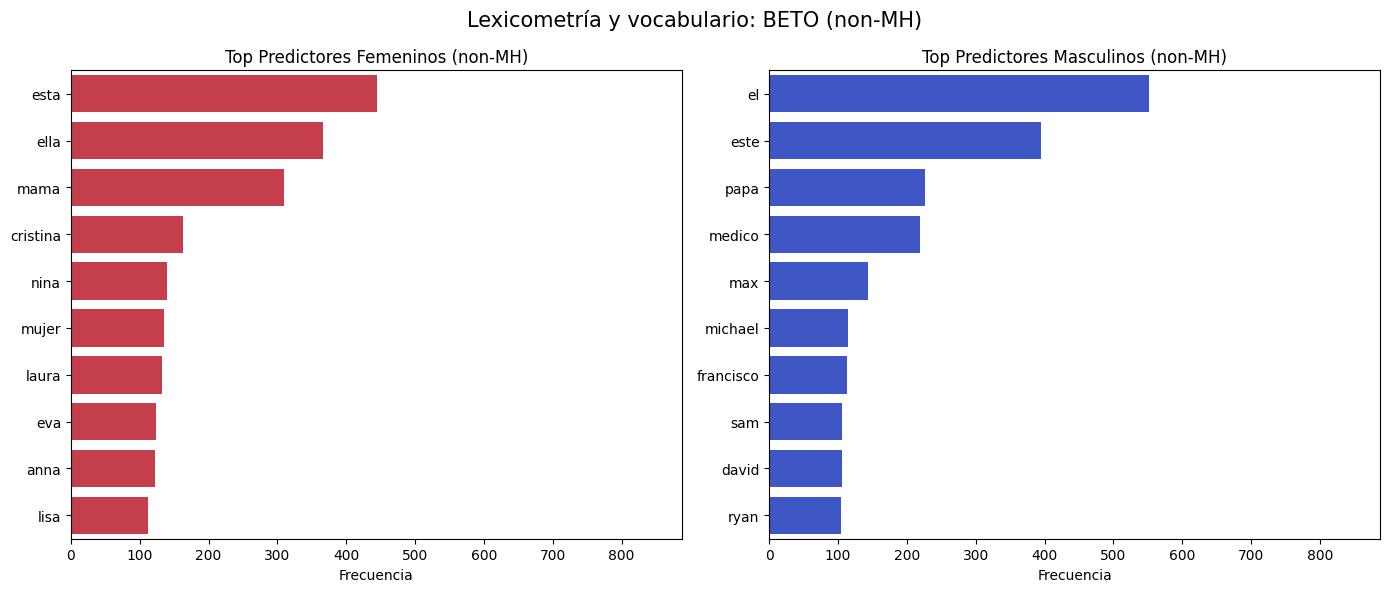

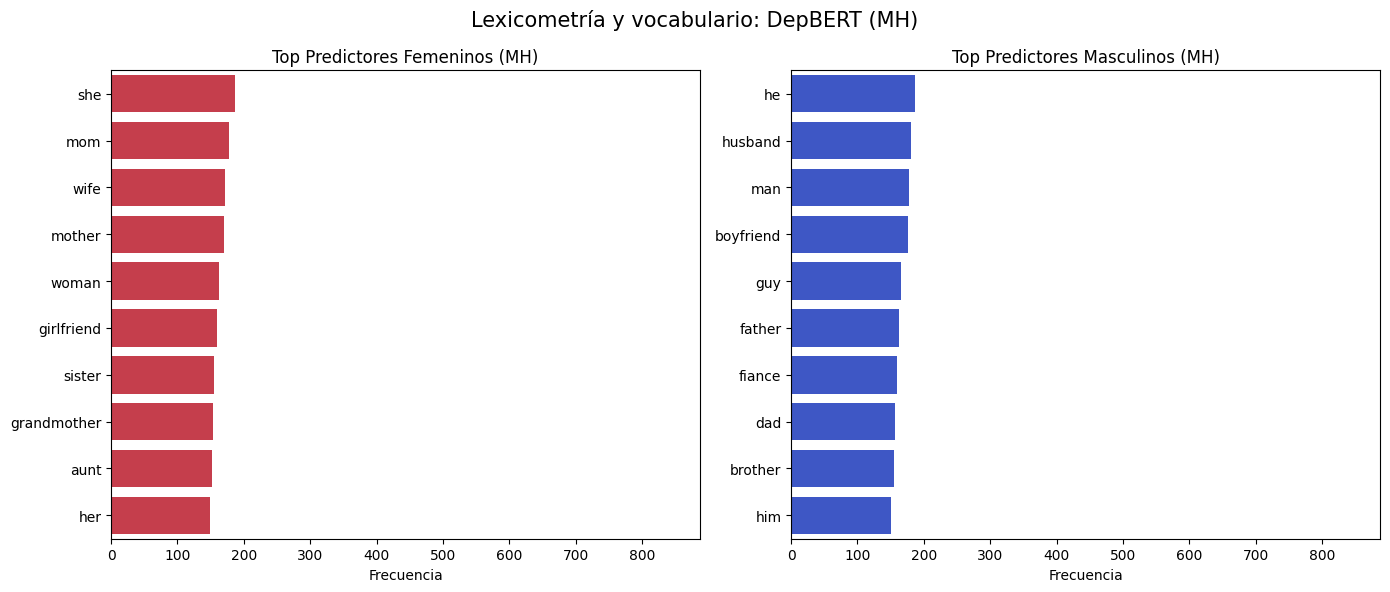

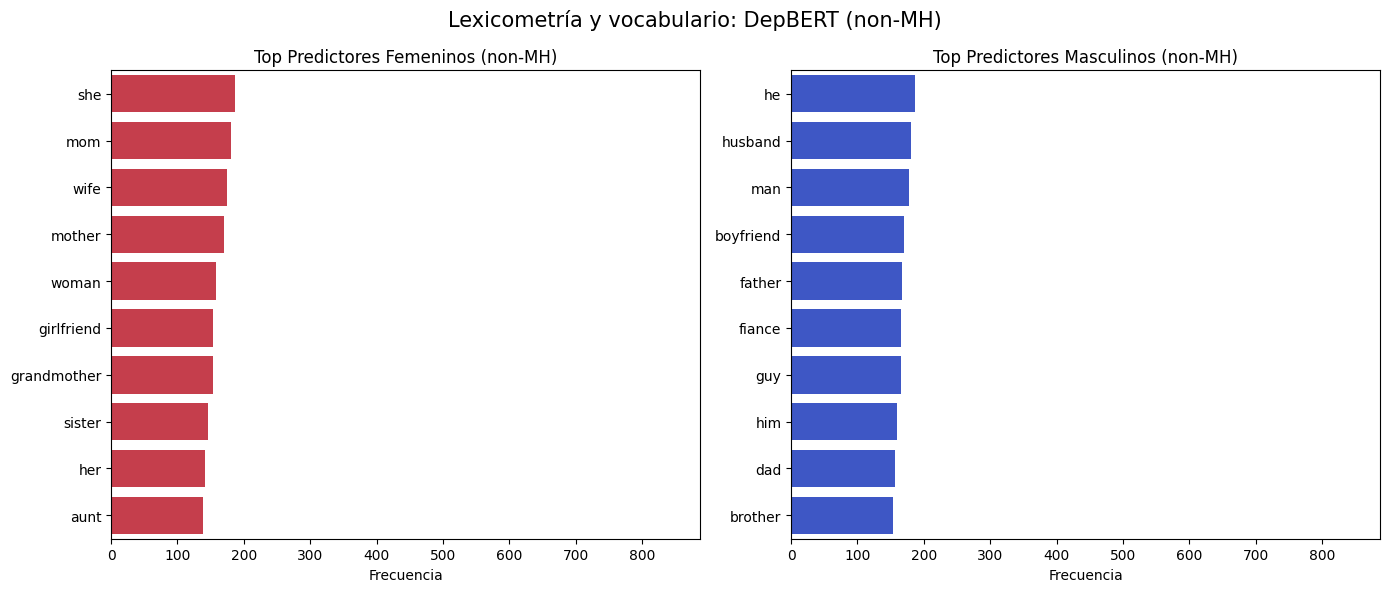

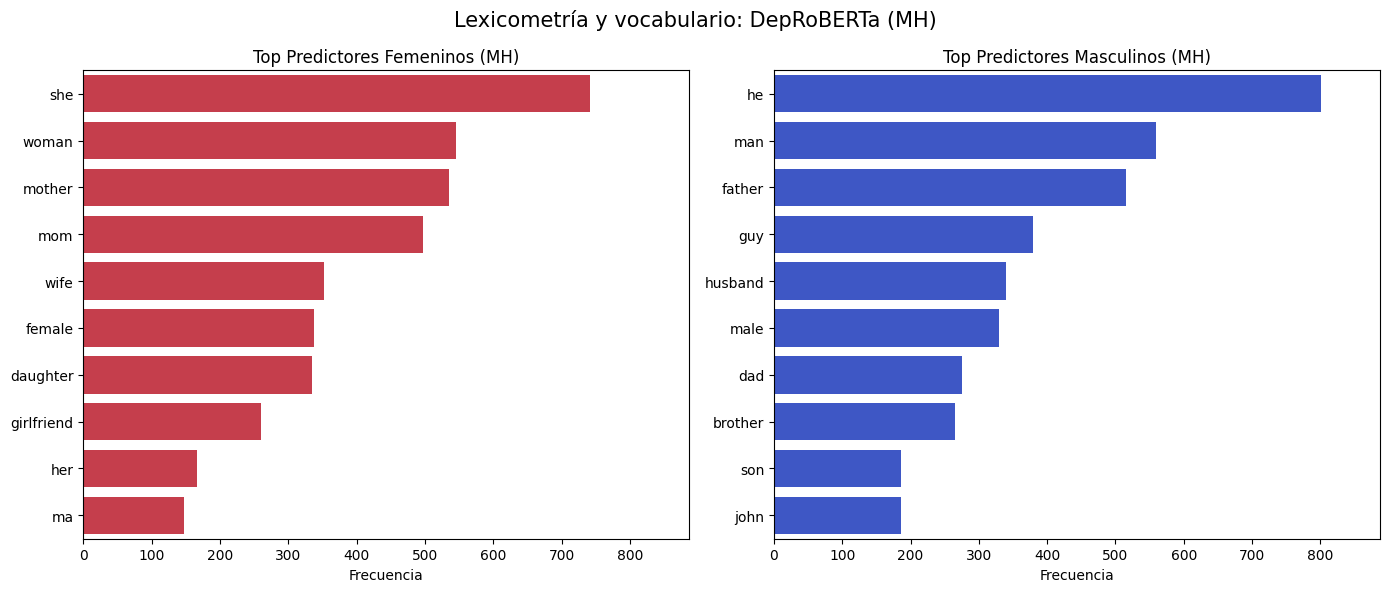

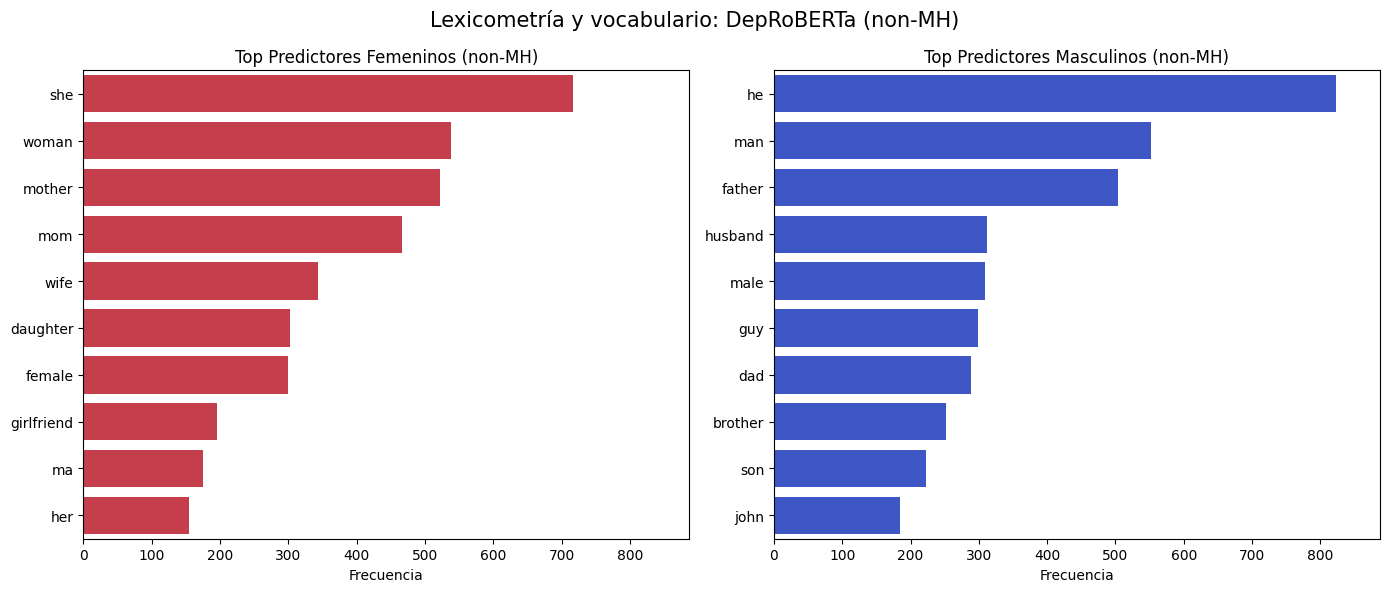

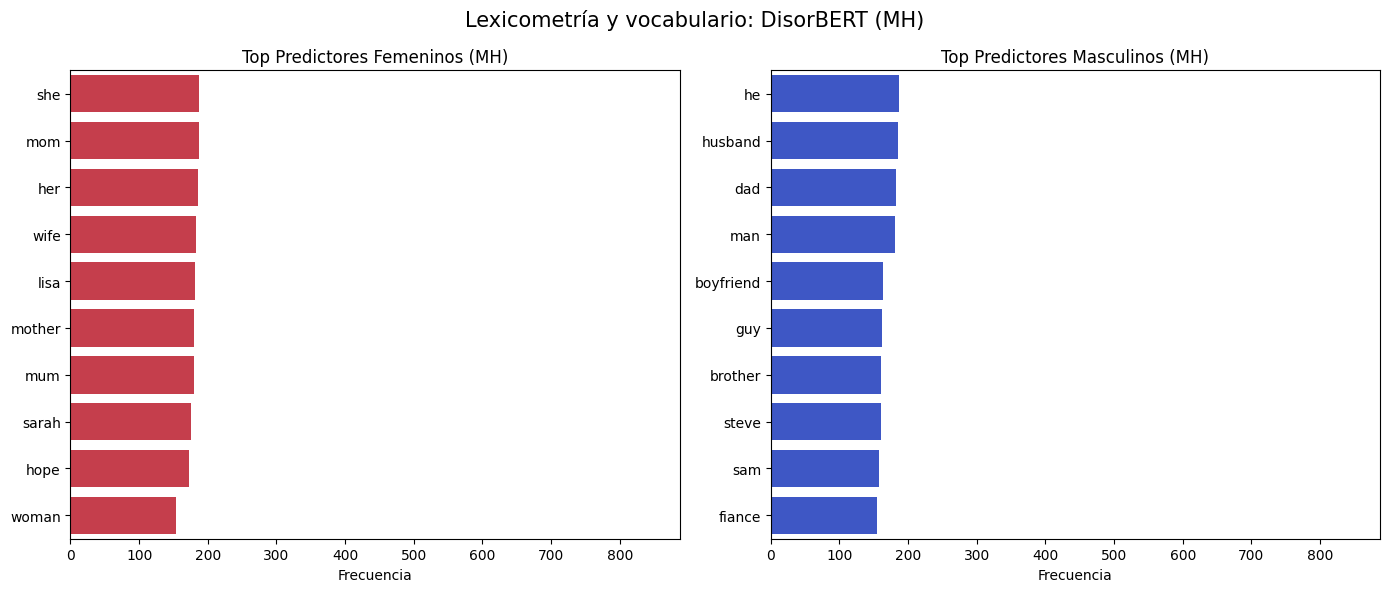

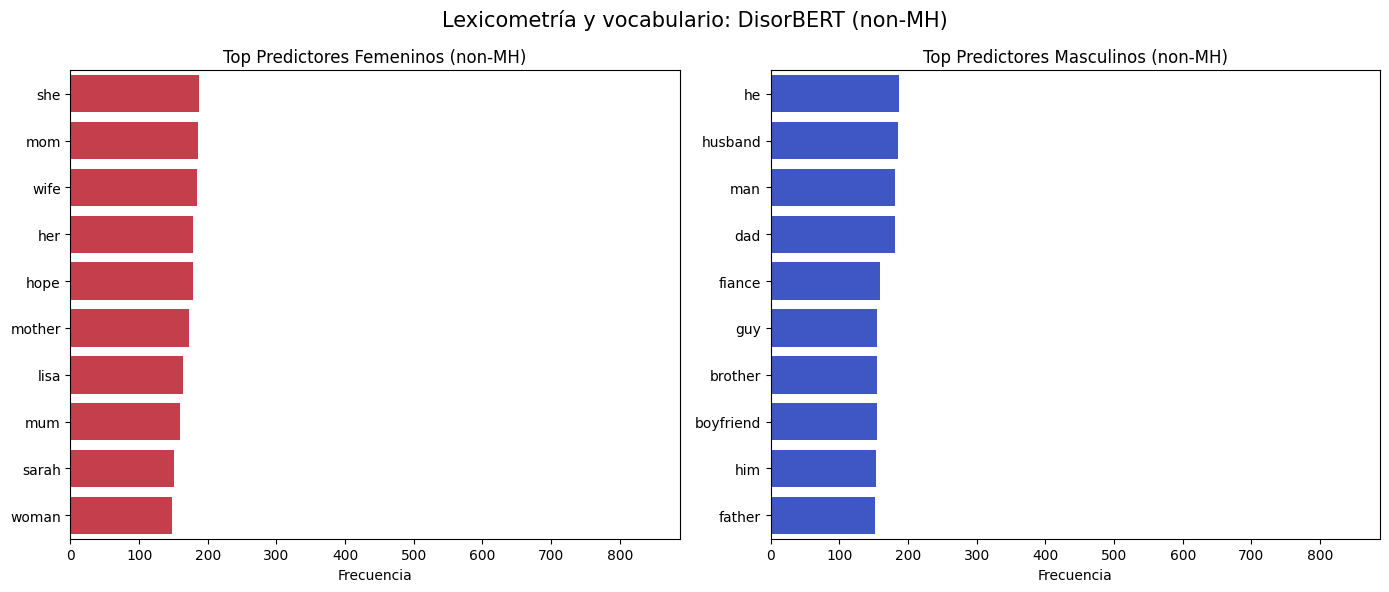

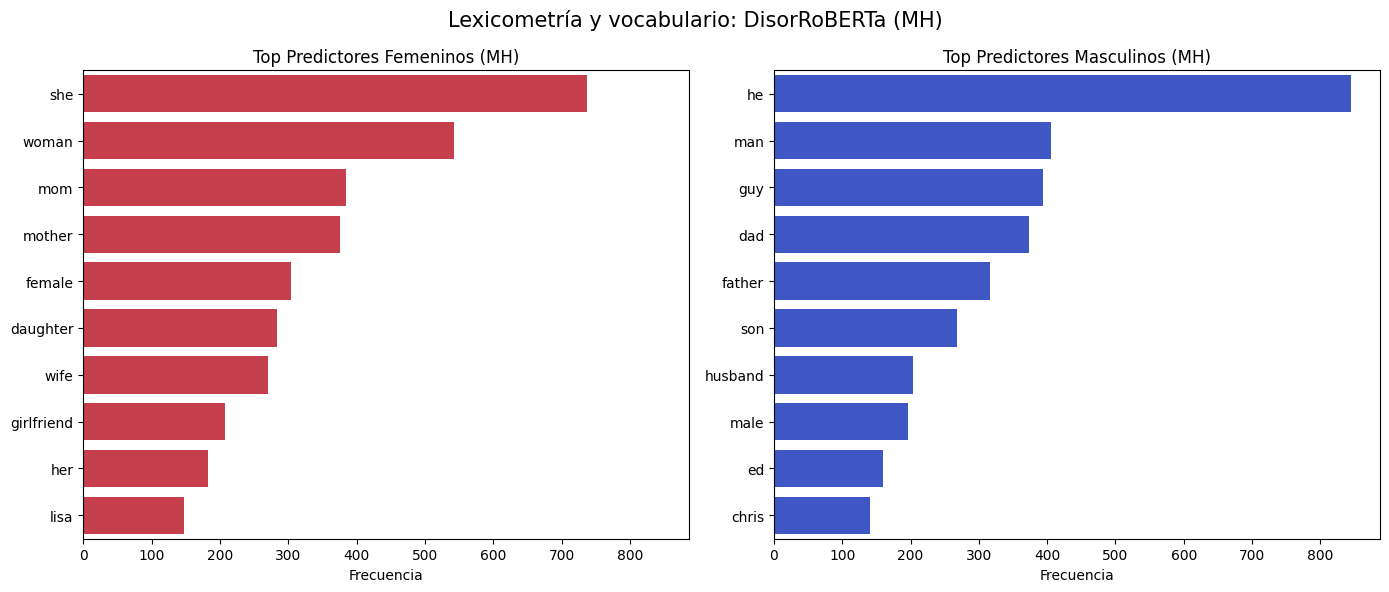

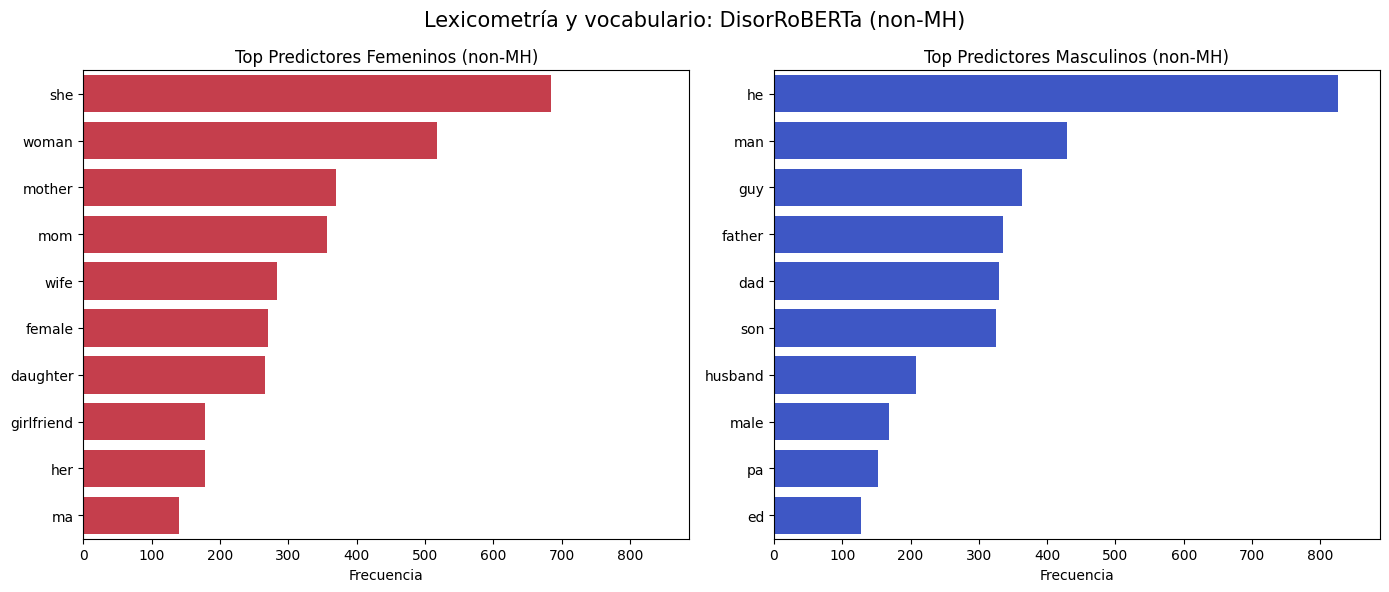

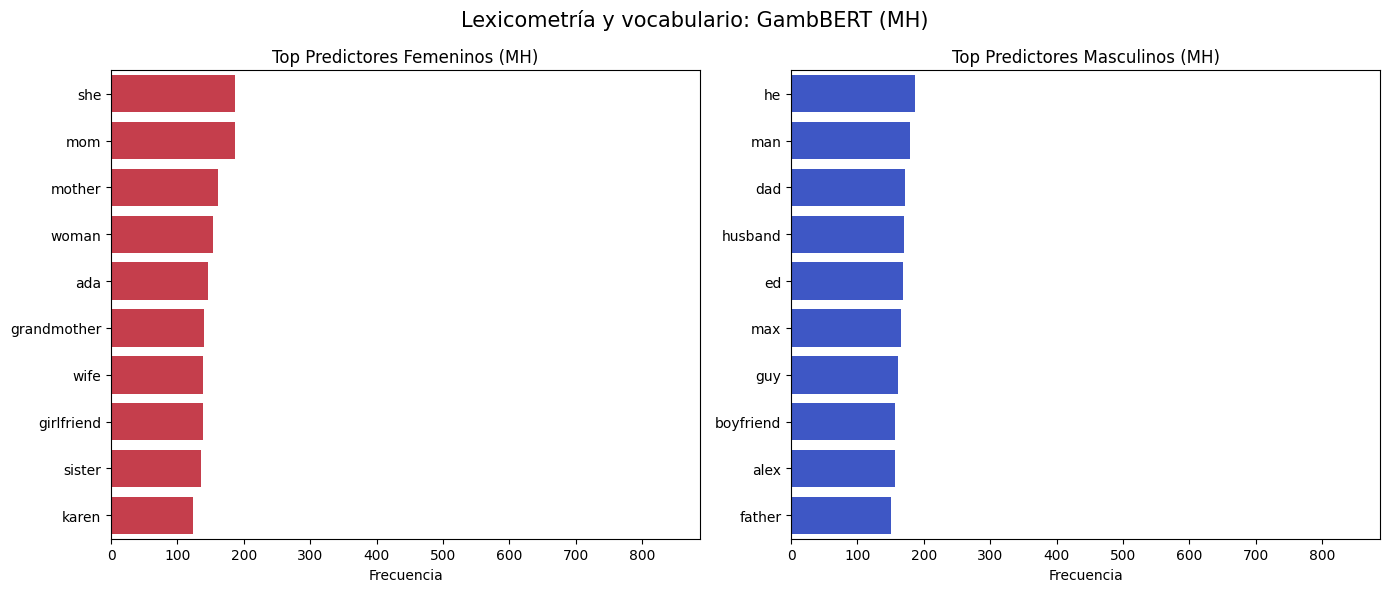

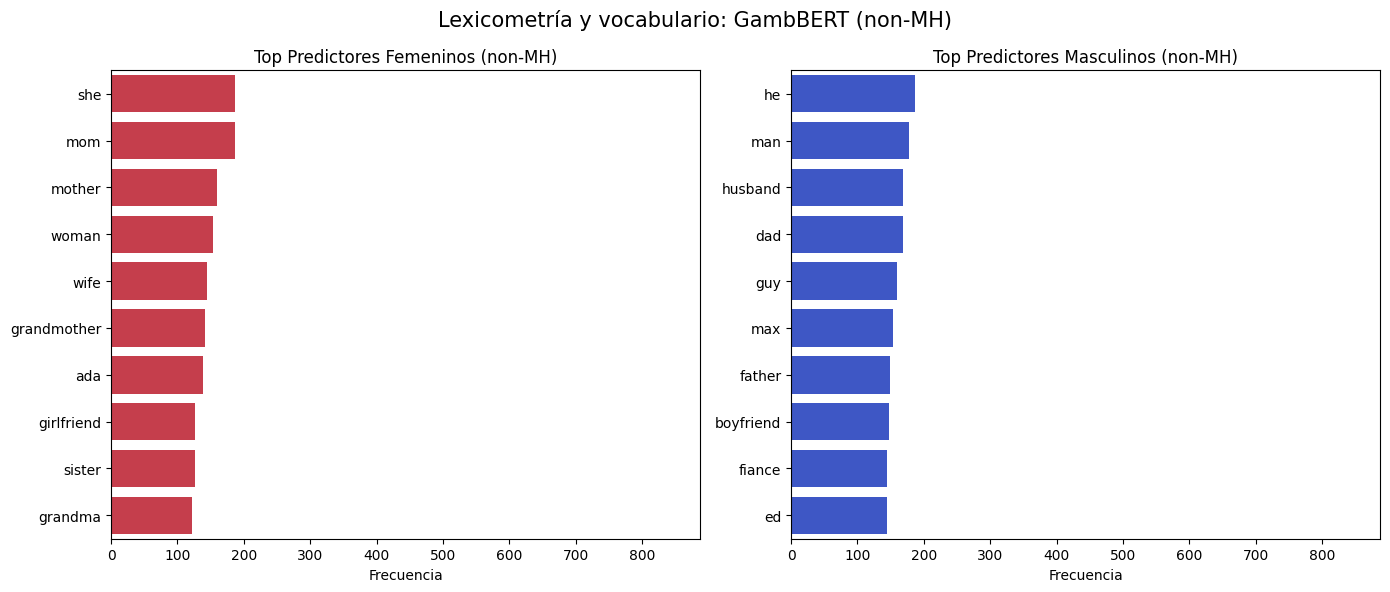

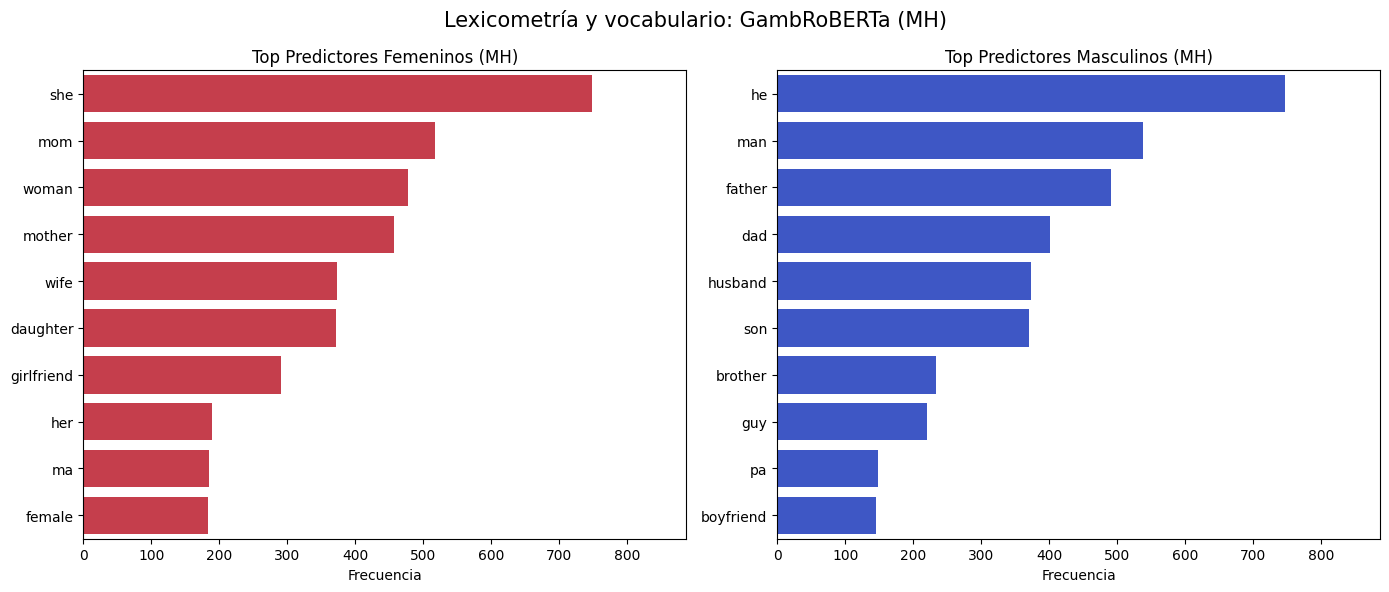

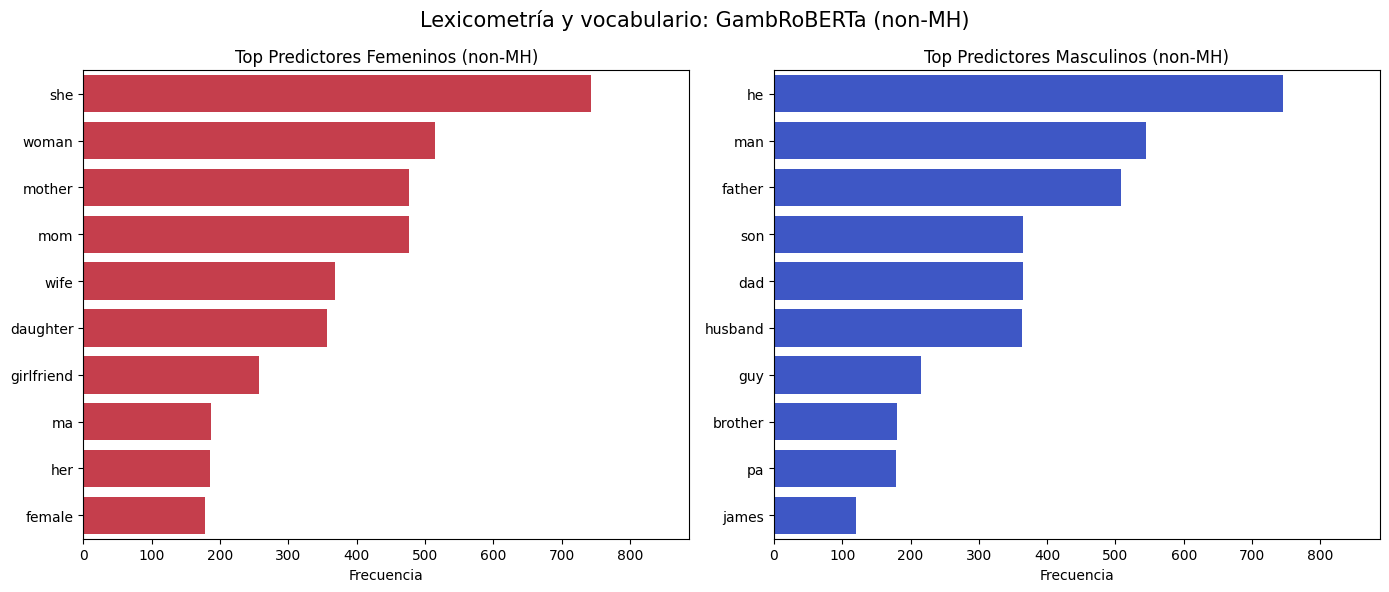

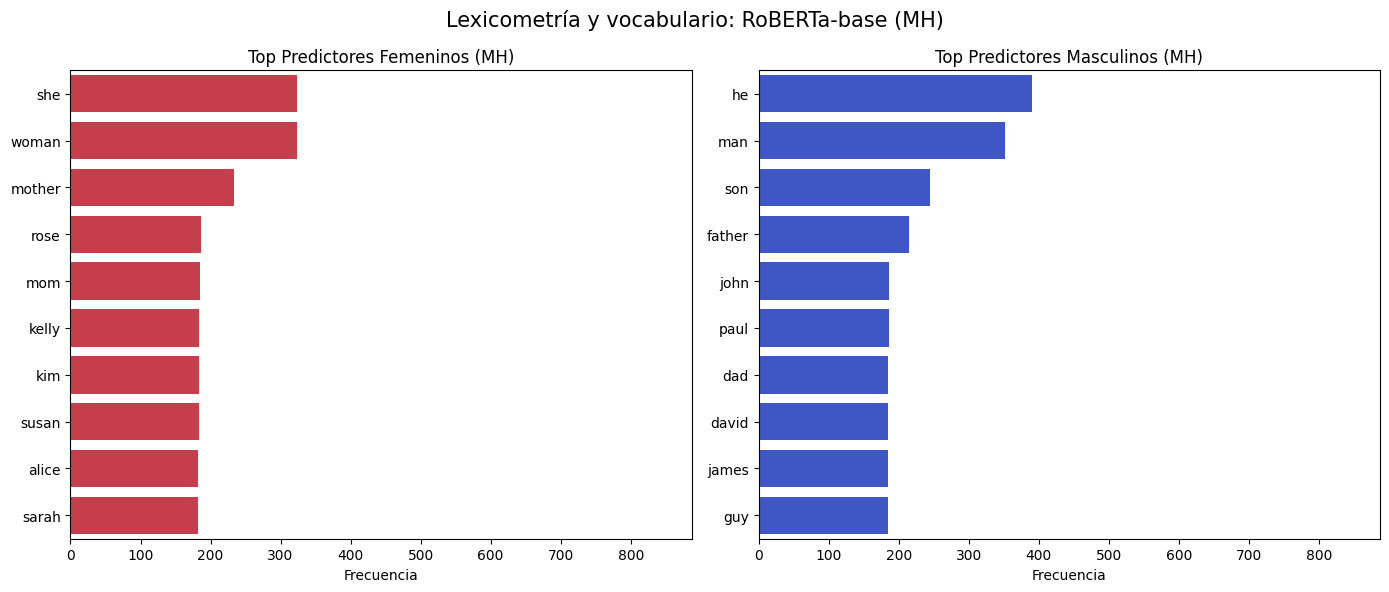

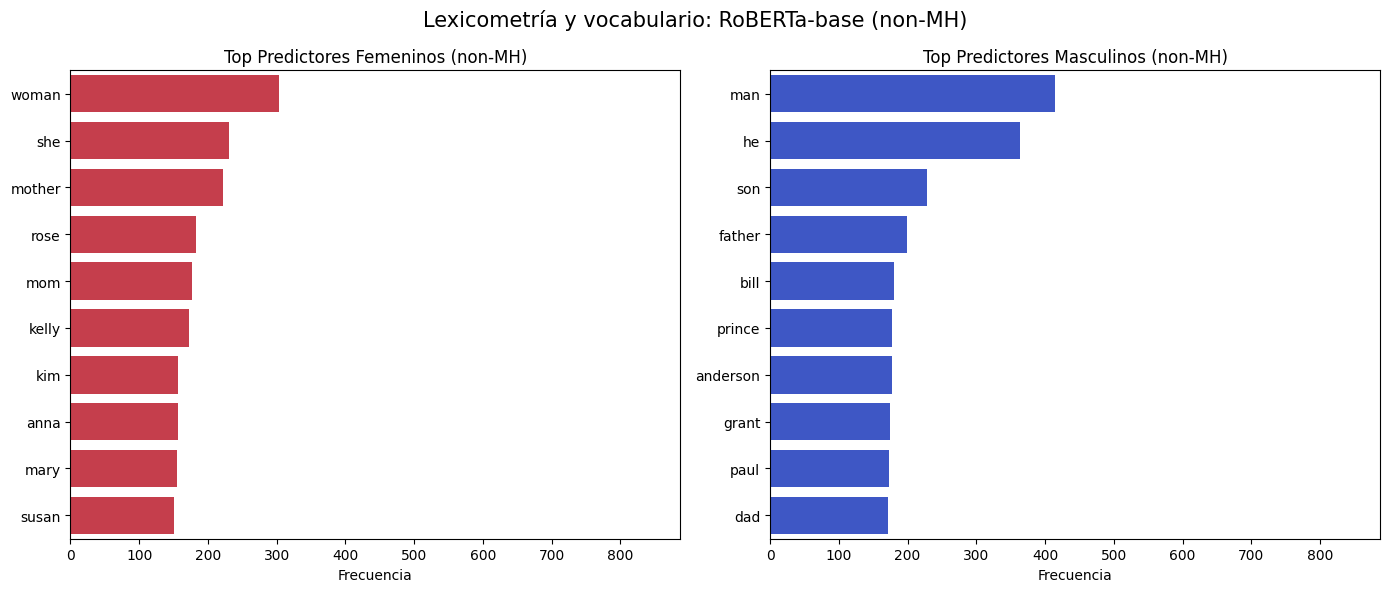

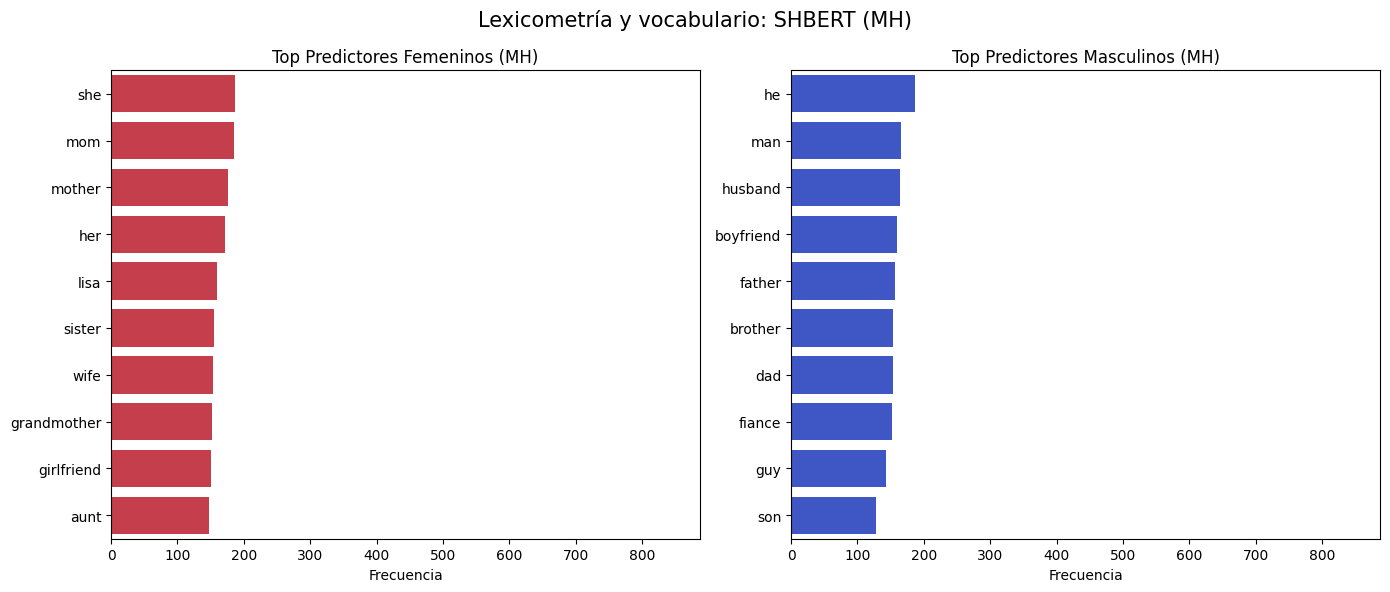

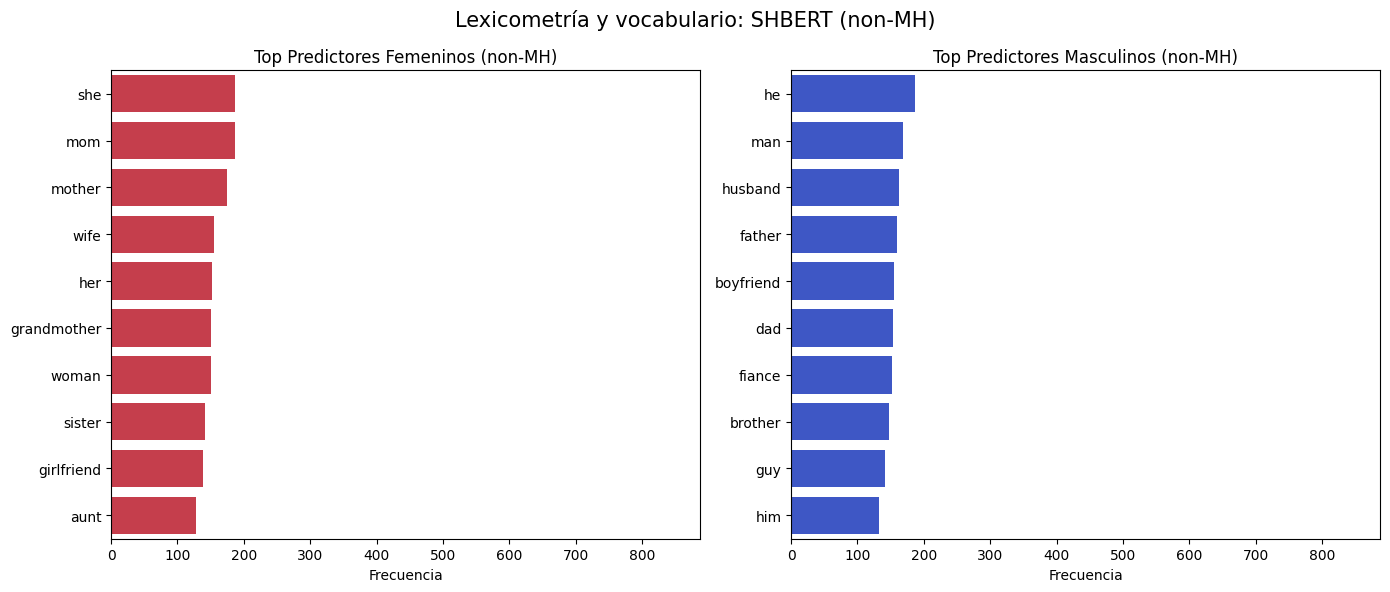

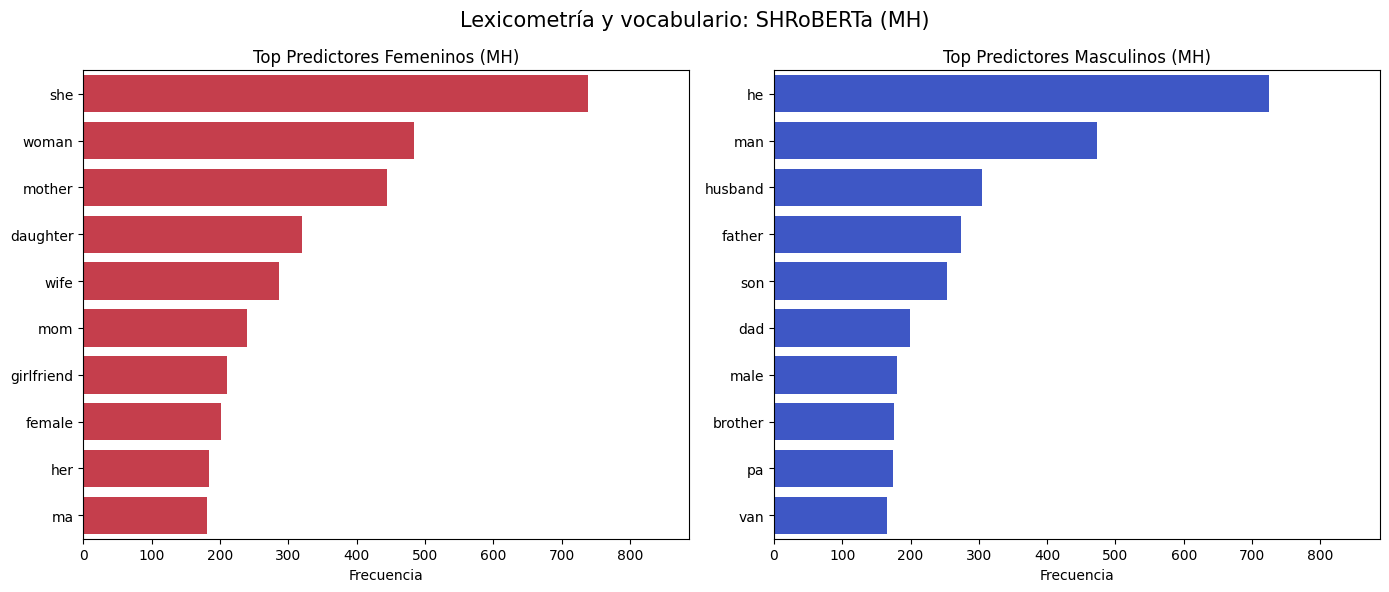

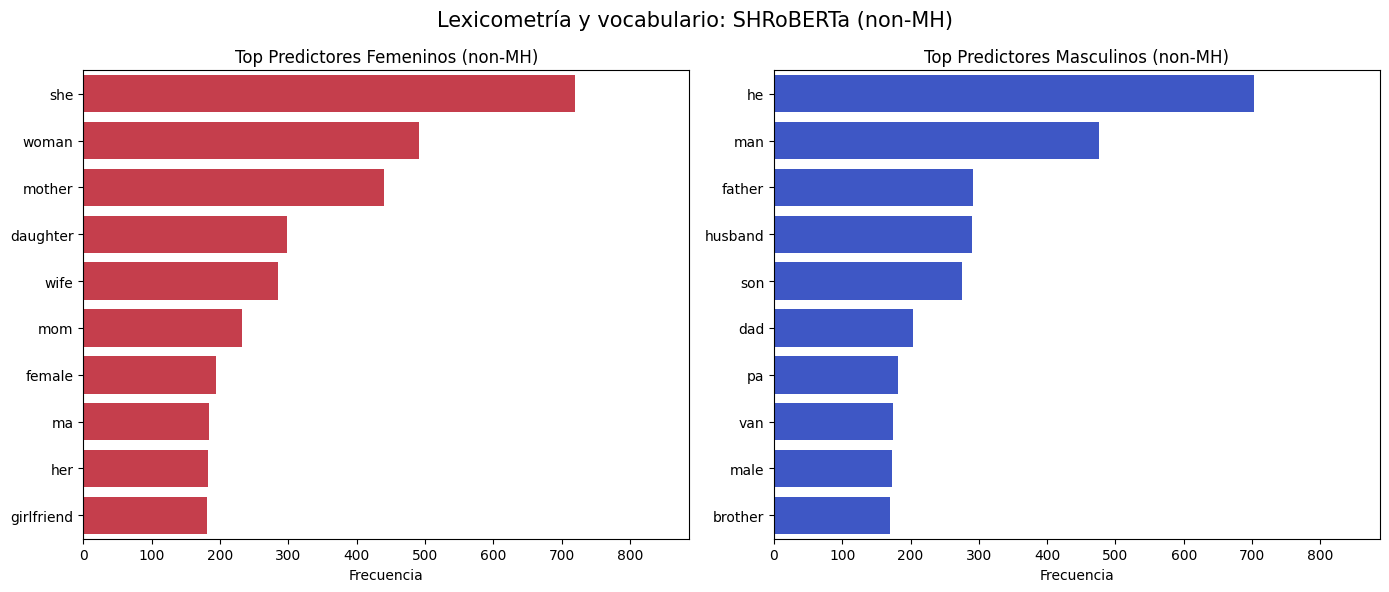

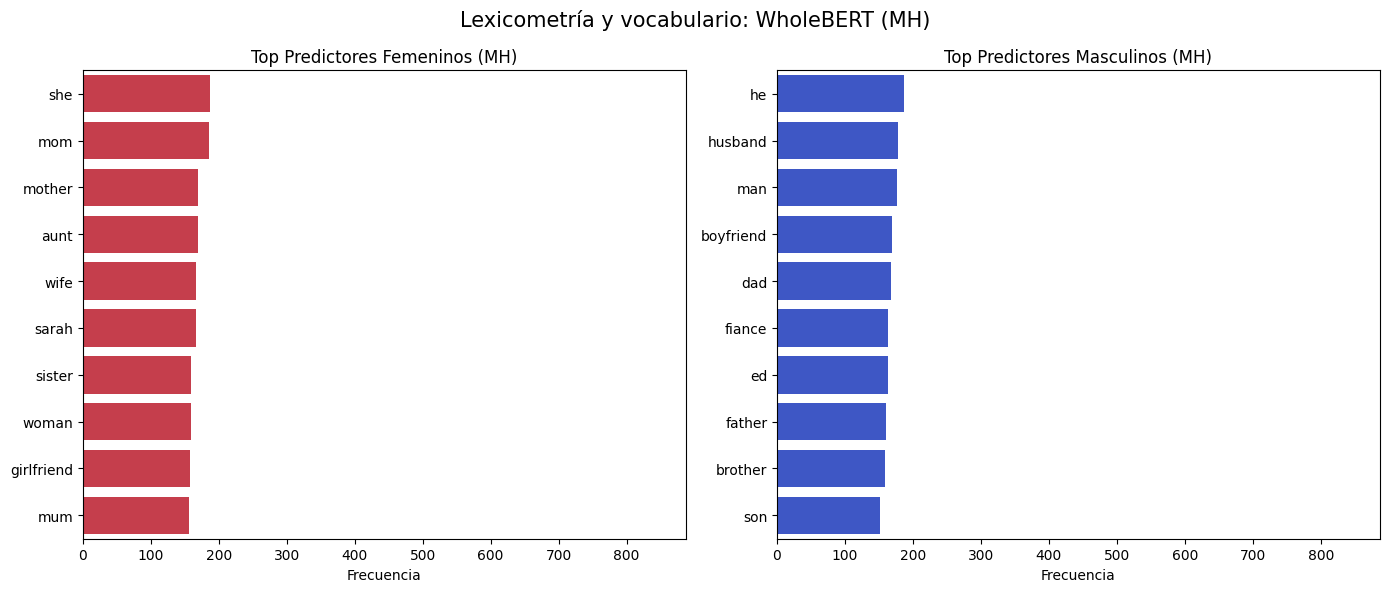

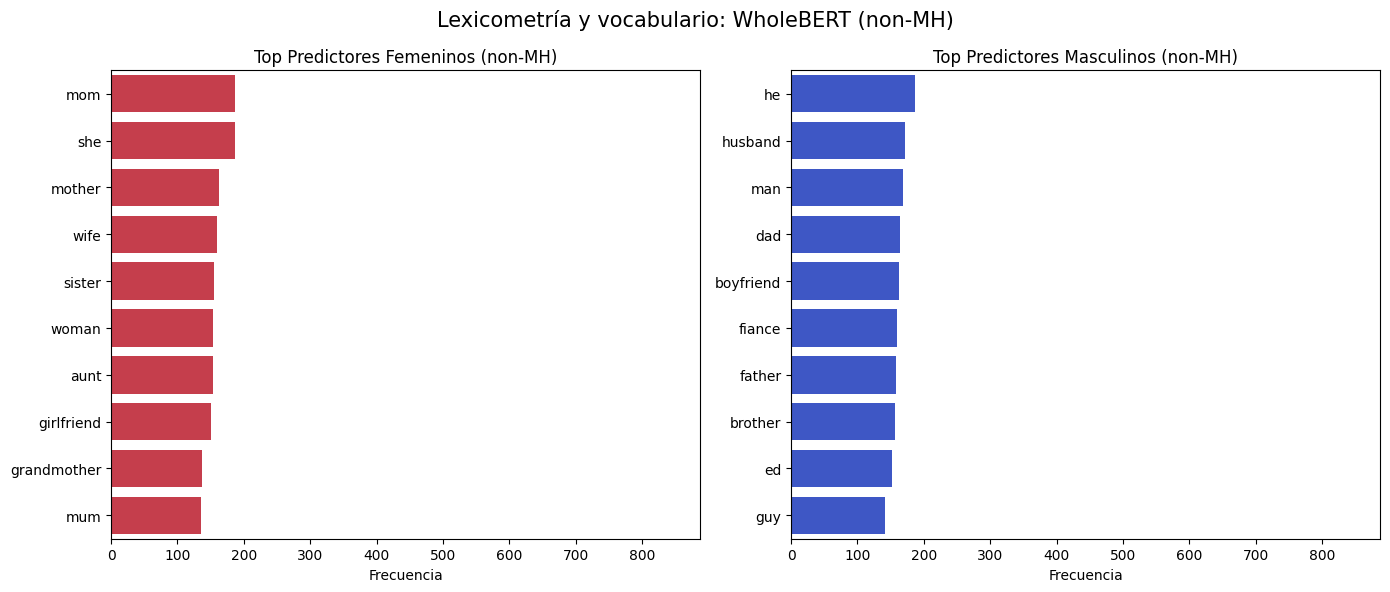

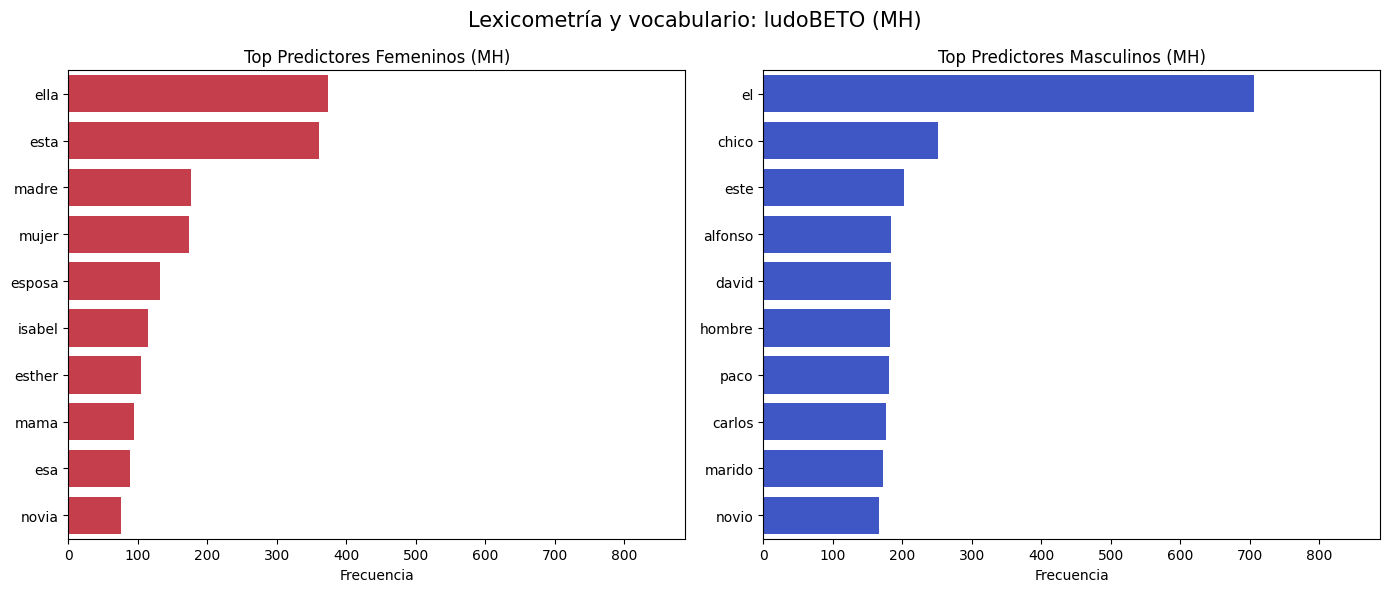

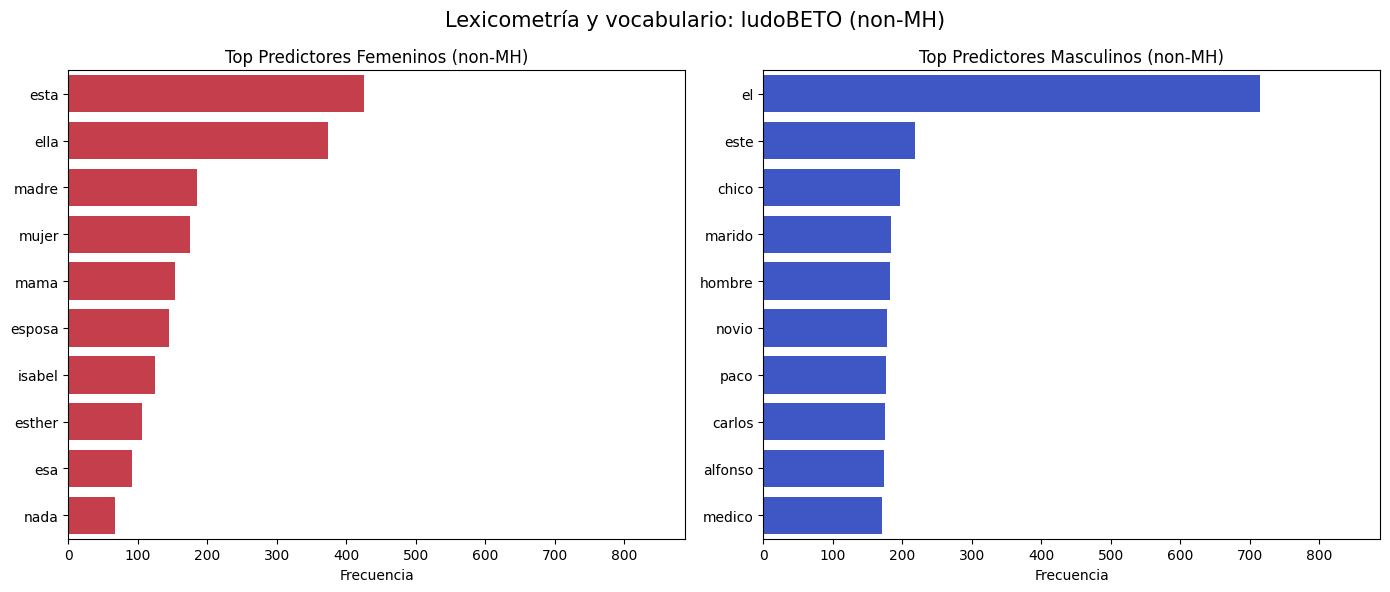

In [3]:
def get_tokens_clean(token_str):
    try:
        # Convierte el string del CSV en lista real de Python
        data = ast.literal_eval(token_str)
        # Limpia "token (0.123)" -> "token"
        return [re.match(r"^(.*) \(", t).group(1).strip() for t in data if "(" in t]
    except: return []

# 1. Pre-procesamiento: Calculamos el máximo global
stats_dict = {}
global_max = 0

# Iteramos por las combinaciones únicas de modelo y tipo de salud
for (model_name, health_type), group_df in full_data.groupby(['model', 'health']):
    f_tokens = []
    m_tokens = []

    for row in group_df['tokens_female']: f_tokens.extend(get_tokens_clean(row))
    for row in group_df['tokens_male']: m_tokens.extend(get_tokens_clean(row))

    top_f = Counter(f_tokens).most_common(10)
    top_m = Counter(m_tokens).most_common(10)

    # Guardamos usando una clave combinada
    stats_dict[(model_name, health_type)] = {'F': top_f, 'M': top_m}

    # Actualizar máximo global
    current_max = max([c for t, c in top_f] + [c for t, c in top_m] + [0])
    if current_max > global_max: global_max = current_max

# 2. Bucle de representación visual
for (model_name, health_type), stats in stats_dict.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    # Colores
    color_f = "#db283a"
    color_m = "#2849db"

    # Gráfico Izquierda: Femenino
    f_df = pd.DataFrame(stats['F'], columns=['Token', 'Frecuencia'])
    sns.barplot(data=f_df, y='Token', x='Frecuencia', ax=axes[0], color=color_f)
    axes[0].set_title(f"Top Predictores Femeninos ({health_type})")
    axes[0].set_xlim(0, global_max * 1.05)
    axes[0].set_ylabel("")

    # Gráfico Derecha: Masculino
    m_df = pd.DataFrame(stats['M'], columns=['Token', 'Frecuencia'])
    sns.barplot(data=m_df, y='Token', x='Frecuencia', ax=axes[1], color=color_m)
    axes[1].set_title(f"Top Predictores Masculinos ({health_type})")
    axes[1].set_ylabel("")

    # Título dinámico que indica el modelo y si es MH o non-MH
    plt.suptitle(f"Lexicometría y vocabulario: {model_name} ({health_type})", fontsize=15)

    plt.tight_layout()
    # Guardado con nombre único para no sobrescribir
    plt.savefig(f"lexicometría y vocabulario/{model_name}_{health_type}.png", dpi=300)
    plt.show()